# **Imports + Setup**

In [2]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

sys.path.append("../../")
from dataset_utils import CassavaDataset

device = torch.device("xpu" if (hasattr(torch, "xpu") and torch.xpu.is_available()) else
                       ("cuda" if torch.cuda.is_available() else "cpu"))
print("Using device:", device)

Using device: xpu


# **Load Data + Label Map**

In [4]:
BASE_DIR = "../../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train_images")

df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))

with open(os.path.join(BASE_DIR, "label_num_to_disease_map.json")) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}

df["disease_name"] = df["label"].map(label_map)
num_classes = df["label"].nunique()
class_names = [label_map[i] for i in range(num_classes)]

print("Classes:", class_names)

Classes: ['Cassava Bacterial Blight (CBB)', 'Cassava Brown Streak Disease (CBSD)', 'Cassava Green Mottle (CGM)', 'Cassava Mosaic Disease (CMD)', 'Healthy']


# **Test Split**

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)
test_df = test_df.reset_index(drop=True)

print("Test set size:", len(test_df))

Test set size: 3210


# **Transform**

In [6]:
IMG_SIZE = 260

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# **Model Architecture**

In [7]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio), nn.ReLU(),
            nn.Linear(in_channels // reduction_ratio, in_channels))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))
        weights = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * weights


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        weights = self.sigmoid(self.conv(combined))
        return x * weights


class DualAttentionBlock(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super().__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attention = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


class AttenLeafNetV2(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base_model = models.efficientnet_b0(weights=None)
        self.backbone = base_model.features
        self.attention = DualAttentionBlock(1280)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(1280, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(512, num_classes))

    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def forward_with_attention_map(self, x):
        features = self.backbone(x)
        channel_refined = self.attention.channel_attention(features)
        avg_out = torch.mean(channel_refined, dim=1, keepdim=True)
        max_out, _ = torch.max(channel_refined, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        attention_map = torch.sigmoid(self.attention.spatial_attention.conv(combined))
        spatial_refined = channel_refined * attention_map
        pooled = self.global_pool(spatial_refined)
        out = self.classifier(torch.flatten(pooled, 1))
        return out, attention_map

# **Trained Final Model Weights**

In [9]:
model = AttenLeafNetV2(num_classes=num_classes)

model.load_state_dict(torch.load("./attenleafnet_v2_final.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


# **Finding One CORRECT and One WRONG Prediction**

In [10]:
correct_example = None
wrong_example = None

with torch.no_grad():
    for idx in range(len(test_df)):
        row = test_df.iloc[idx]
        img_path = os.path.join(TRAIN_DIR, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        input_tensor = eval_transform(image).unsqueeze(0).to(device)

        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()
        true_label = row["label"]

        if pred == true_label and correct_example is None:
            correct_example = {"image": image, "path": img_path, "true": true_label, "pred": pred}

        if pred != true_label and wrong_example is None:
            wrong_example = {"image": image, "path": img_path, "true": true_label, "pred": pred}

        if correct_example and wrong_example:
            break

print("Correct example -> True:", label_map[correct_example["true"]], "| Predicted:", label_map[correct_example["pred"]])
print("Wrong example   -> True:", label_map[wrong_example["true"]], "| Predicted:", label_map[wrong_example["pred"]])

Correct example -> True: Cassava Mosaic Disease (CMD) | Predicted: Cassava Mosaic Disease (CMD)
Wrong example   -> True: Cassava Brown Streak Disease (CBSD) | Predicted: Cassava Green Mottle (CGM)


# **Grad-CAM Setup**

In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = [model.backbone[-1]]  # last conv layer of the EfficientNet-B0 backbone
cam = GradCAM(model=model, target_layers=target_layer)

def run_gradcam(example, title):
    image = example["image"].resize((IMG_SIZE, IMG_SIZE))
    input_tensor = eval_transform(example["image"]).unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
    rgb_img = np.array(image).astype(np.float32) / 255.0
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"Original\nTrue: {label_map[example['true']]}")
    axes[0].axis("off")

    axes[1].imshow(cam_image)
    axes[1].set_title(f"Grad-CAM\nPredicted: {label_map[example['pred']]}")
    axes[1].axis("off")

    plt.suptitle(title, fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig(f"gradcam_{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

# **Grad-CAM on Both Examples**

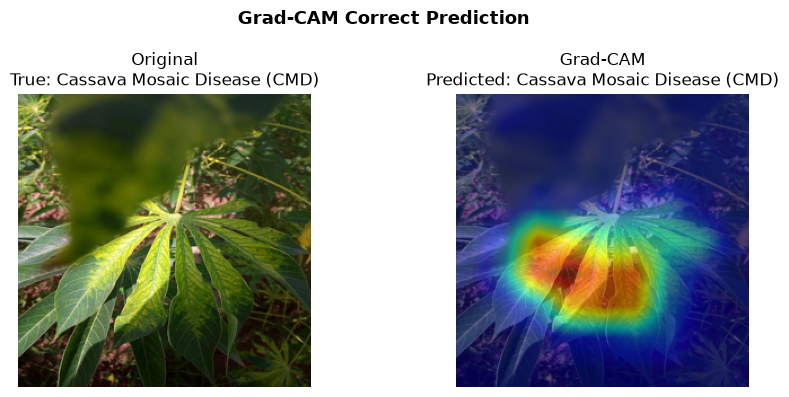

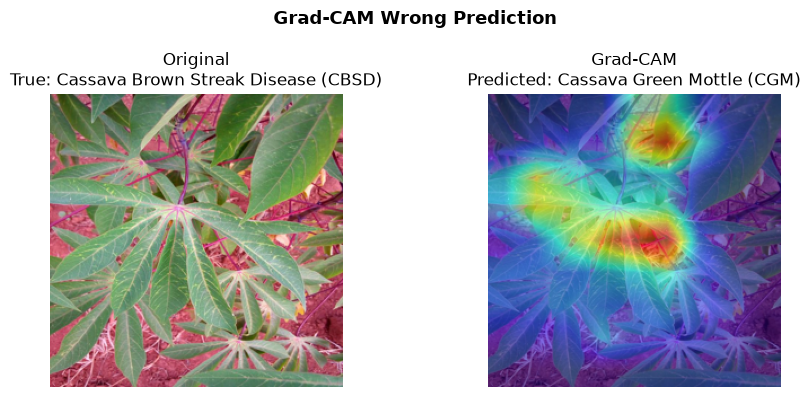

In [13]:
run_gradcam(correct_example, "Grad-CAM Correct Prediction")
run_gradcam(wrong_example, "Grad-CAM Wrong Prediction")

# **LIME Setup**

In [14]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def predict_fn(images):
    """LIME needs a function that takes a batch of numpy images and returns class probabilities"""
    model.eval()
    batch = torch.stack([eval_transform(Image.fromarray(img)) for img in images]).to(device)
    with torch.no_grad():
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
    return probs

explainer = lime_image.LimeImageExplainer()

def run_lime(example, title):
    image_resized = example["image"].resize((IMG_SIZE, IMG_SIZE))
    image_np = np.array(image_resized)

    explanation = explainer.explain_instance(
        image_np, predict_fn, top_labels=5, hide_color=0, num_samples=500
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(image_np)
    axes[0].set_title(f"Original\nTrue: {label_map[example['true']]}")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title(f"LIME\nPredicted: {label_map[example['pred']]}")
    axes[1].axis("off")

    plt.suptitle(title, fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig(f"lime_{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

# **LIME on Both Examples**

  0%|          | 0/500 [00:00<?, ?it/s]

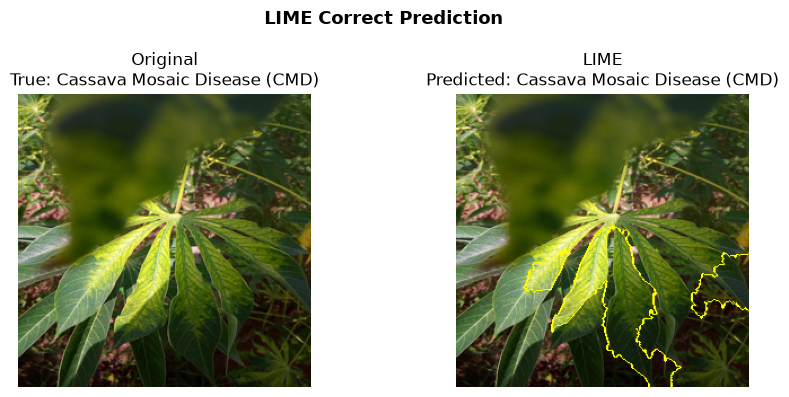

  0%|          | 0/500 [00:00<?, ?it/s]

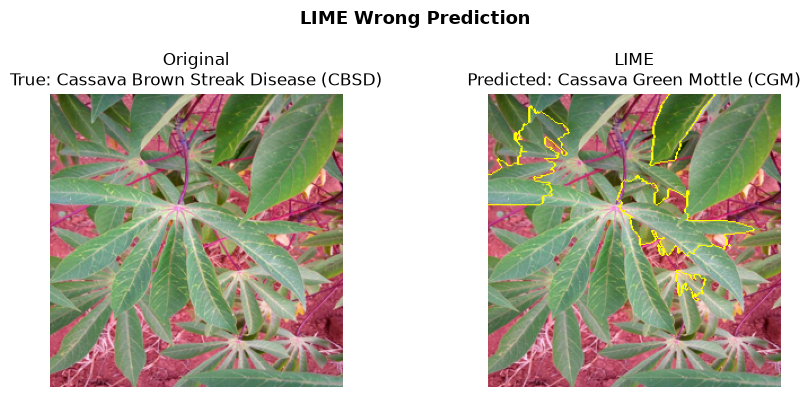

In [15]:
run_lime(correct_example, "LIME Correct Prediction")
run_lime(wrong_example, "LIME Wrong Prediction")

# **Side-by-Side Summary (Grad-CAM + LIME)**

  0%|          | 0/500 [00:00<?, ?it/s]

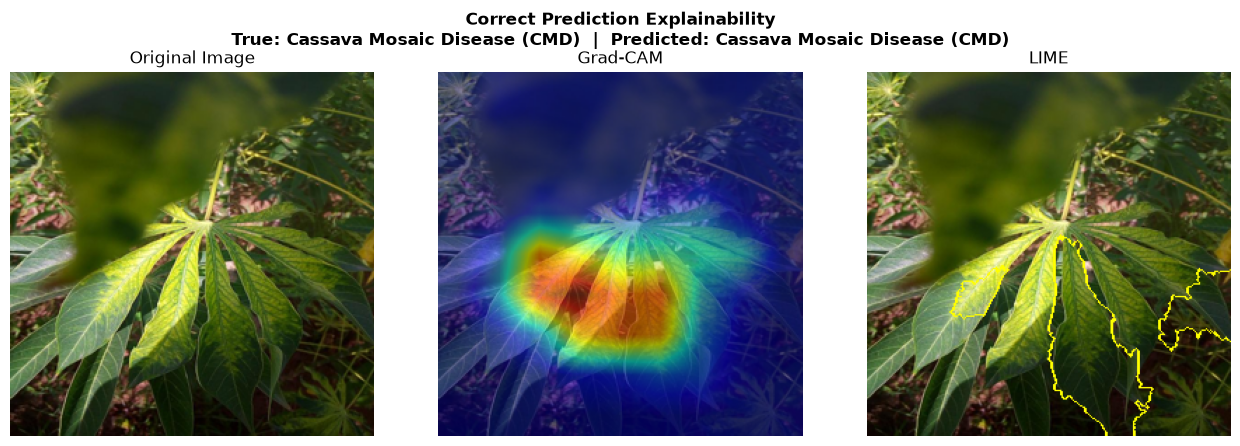

  0%|          | 0/500 [00:00<?, ?it/s]

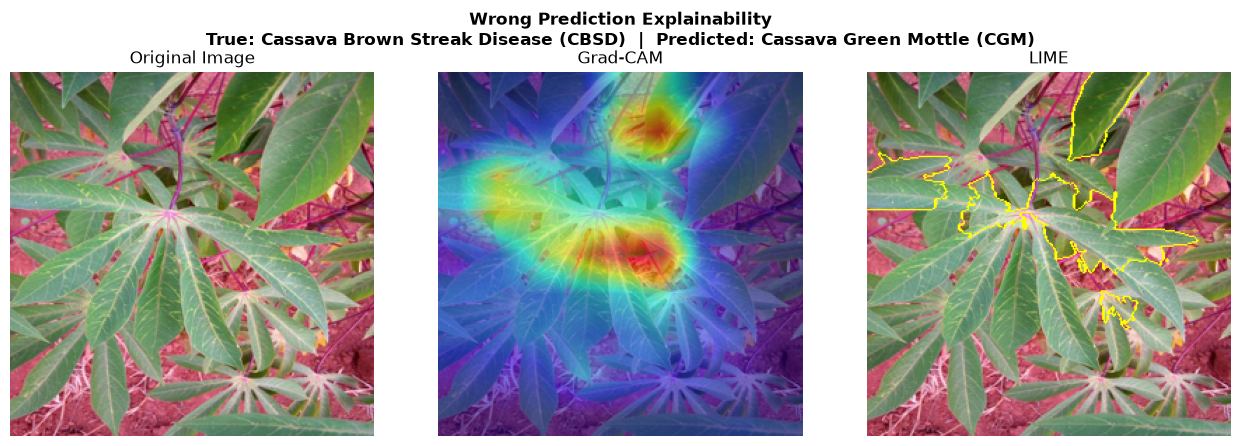

In [16]:
def full_explainability_panel(example, title):
    image = example["image"].resize((IMG_SIZE, IMG_SIZE))
    image_np = np.array(image)

    # Grad-CAM
    input_tensor = eval_transform(example["image"]).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
    rgb_img = image_np.astype(np.float32) / 255.0
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # LIME
    explanation = explainer.explain_instance(image_np, predict_fn, top_labels=5, hide_color=0, num_samples=500)
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    lime_image_out = mark_boundaries(temp, mask)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    axes[0].imshow(image_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(cam_image)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(lime_image_out)
    axes[2].set_title("LIME")
    axes[2].axis("off")

    plt.suptitle(f"{title}\nTrue: {label_map[example['true']]}  |  Predicted: {label_map[example['pred']]}",
                 fontsize=12, weight="bold")
    plt.tight_layout()
    plt.savefig(f"xai_panel_{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

full_explainability_panel(correct_example, "Correct Prediction Explainability")
full_explainability_panel(wrong_example, "Wrong Prediction Explainability")